# DM Python pour la Datascience

## Import des données

In [2]:
import pandas as pd
from great_tables import GT, style, loc, md
from matplotlib import pyplot as plt
from utils import load_data, build_code_commune, build_candidat, build_score_departements, compute_scores_nationaux

In [3]:
df = load_data()
df.head()

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
0,01,Ain,001,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3
1,01,Ain,002,L'Abergement-de-Varey,Nathalie,ARTHAUD,2
2,01,Ain,004,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38
3,01,Ain,005,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8
4,01,Ain,006,Ambléon,Nathalie,ARTHAUD,0


## 1. Explorations générales
### Question 1

In [4]:
df = build_code_commune(df)
df = build_candidat(df)
df.sample(5)

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix,candidat
479618,57,Moselle,57714,Haute-Vigneulles,NaN,blancs,4,NaN
199865,62,Pas-de-Calais,62142,Blingel,Éric,ZEMMOUR,3,Éric ZEMMOUR
366890,38,Isère,38462,Saint-Théoffrey,Philippe,POUTOU,5,Philippe POUTOU
207421,80,Somme,80221,Cramont,Éric,ZEMMOUR,15,Éric ZEMMOUR
253138,19,Corrèze,19128,Margerides,Anne,HIDALGO,1,Anne HIDALGO


### Question 2

In [5]:
candidats = df["candidat"].dropna().nunique()
print(f"En 2022, il y avait {candidats} candidats à l'élection présidentielle.")

En 2022, il y avait 12 candidats à l'élection présidentielle.


### Question 3

In [6]:
scores_nationaux = compute_scores_nationaux(df)
scores_nationaux.insert(0, 'rang', range(1, len(scores_nationaux) + 1))

scores_nationaux['voix_fmt'] = scores_nationaux['voix'].apply(lambda x: f"{x:,.0f}".replace(",", " "))
scores_nationaux['pct_fmt'] = scores_nationaux['score_national'].apply(lambda x: f"{x:.2f} %")

(
    GT(scores_nationaux[["candidat", "voix_fmt", "pct_fmt"]])
    .tab_header(title=md("**Election**"), subtitle="Résultats du premier tour (📅 10 avril 2022)")
    .tab_style(style=style.text(font="Times New Roman"), locations=loc.body())
    .tab_style(style=style.text(font="Times New Roman"), locations=loc.column_labels())
    .tab_style(style=style.text(font="Times New Roman", align="center"), locations=loc.title())
    .tab_style(style=style.text(font="Times New Roman", align="center"), locations=loc.subtitle())
    .cols_label(candidat="Candidat", voix_fmt="Nombre votes (total)", pct_fmt="Score (% votes exprimés)")
)

GT(_tbl_data=                 candidat   voix_fmt  pct_fmt
0         Emmanuel MACRON  9 783 058  27.85 %
1           Marine LE PEN  8 133 828  23.15 %
2      Jean-Luc MÉLENCHON  7 712 520  21.95 %
3            Éric ZEMMOUR  2 485 226   7.07 %
4        Valérie PÉCRESSE  1 679 001   4.78 %
5           Yannick JADOT  1 627 853   4.63 %
6           Jean LASSALLE  1 101 387   3.13 %
7          Fabien ROUSSEL    802 422   2.28 %
8   Nicolas DUPONT-AIGNAN    725 176   2.06 %
9            Anne HIDALGO    616 478   1.75 %
10        Philippe POUTOU    268 904   0.77 %
11       Nathalie ARTHAUD    197 094   0.56 %, _body=<great_tables._gt_data.Body object at 0x7f7a0c489940>, _boxhead=Boxhead([ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='voix_fmt', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre votes (total)', column_align='right', column_width=None), ColInfo(var='pct_fmt', type=<ColInfoTypeEnum.default: 1>, column_label='Score (% votes exprimés)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f7a0c488c20>, _spanners=Spanners([]), _heading=Heading(title=Md(text='**Election**'), subtitle='Résultats du premier tour (📅 10 avril 2022)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f7a0c489fd0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f7a0c5ede50>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='candidat', rownum=0, colnum=None, styles=[CellStyleText(color=None, font='Times New Roman', size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='candidat', rownum=1, colnum=None, styles=[CellStyleText(color=None, font='Times New Roman', size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='candidat', rownum=2, colnum=None, styles=[CellStyleText(color=None, font='Times New Roman', size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='candidat', rownum=3, colnum=None, styles=[CellStyleText(color=None, font='Times New Roman', size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='candidat', rownum=4, colnum=None, styles=[CellStyleText(color=None, font='Times New Roman', size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='candidat', rownum=5, colnum=None, styles=[CellStyleText(color=None, font='Times New Roman', size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='candidat', rownum=6, colnum=None, styles=[CellStyleText(color=None, font='Times New Roman', size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='candidat', rownum=7, colnum=None, styles=[CellStyleText(color=None, font='Times New Roman', size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, r

## 2. Comparaison des scores départements aux moyennes nationales
### Question 4

In [7]:
score_departements = build_score_departements(df)

score_departement_11 = (
    score_departements[score_departements["code_departement"] == "11"]
    .sort_values("score_departement", ascending=False)
    .reset_index(drop=True)
)
score_departement_11["score_fmt"] = score_departement_11["score_departement"].apply(lambda x: f"{x:.2f} %")

(
    GT(score_departement_11[["code_departement", "candidat", "votes_departement", "score_fmt"]])
    .tab_style(style=style.text(font="Times New Roman"), locations=loc.body())
    .tab_style(style=style.text(font="Times New Roman"), locations=loc.column_labels())
)

code_departement,candidat,votes_departement,score_fmt
11,Marine LE PEN,64027,30.14 %
11,Emmanuel MACRON,43104,20.29 %
11,Jean-Luc MÉLENCHON,42039,19.79 %
11,Éric ZEMMOUR,18434,8.68 %
11,Jean LASSALLE,12382,5.83 %
11,Valérie PÉCRESSE,7350,3.46 %
11,Yannick JADOT,6322,2.98 %
11,Anne HIDALGO,6166,2.90 %
11,Fabien ROUSSEL,5622,2.65 %
11,Nicolas DUPONT-AIGNAN,4206,1.98 %


### Question 5

In [8]:
score_departement_11 = (
    score_departements[score_departements["code_departement"] == "11"]
    .sort_values("score_departement", ascending=False)
    .reset_index(drop=True)
)
score_departement_11["score_departement"] = score_departement_11["score_departement"].apply(lambda x: f"{x:.2f} %")
score_departement_11["score_national"] = score_departement_11["score_national"].apply(lambda x: f"{x:.2f} %")

(
    GT(score_departement_11[["code_departement", "candidat", "votes_departement", "score_departement", "votes_national", "score_national"]].head(5))
    .tab_style(style=style.text(font="Times New Roman"), locations=loc.body())
    .tab_style(style=style.text(font="Times New Roman"), locations=loc.column_labels())
)

code_departement,candidat,votes_departement,score_departement,votes_national,score_national
11,Marine LE PEN,64027,30.14 %,8133828,23.15 %
11,Emmanuel MACRON,43104,20.29 %,9783058,27.85 %
11,Jean-Luc MÉLENCHON,42039,19.79 %,7712520,21.95 %
11,Éric ZEMMOUR,18434,8.68 %,2485226,7.07 %
11,Jean LASSALLE,12382,5.83 %,1101387,3.13 %


### Question 6

In [9]:
# La surreprésentation est déjà calculée (×100) dans build_score_departements(dans utils)
score_departements.sample(10)

,code_departement,candidat,votes_departement,score_departement,votes_national,score_national,surrepresentation
562,46,Yannick JADOT,4603,4.21,1627853,4.63,-9.07
77,07,Marine LE PEN,49594,25.18,8133828,23.15,8.77
625,52,Emmanuel MACRON,21886,23.33,9783058,27.85,-16.23
987,82,Jean LASSALLE,9573,6.56,1101387,3.13,109.58
399,33,Jean LASSALLE,37725,4.23,1101387,3.13,35.14
1199,974,Éric ZEMMOUR,13070,3.77,2485226,7.07,-46.68
979,81,Nicolas DUPONT-AIGNAN,5123,2.23,725176,2.06,8.25
32,03,Philippe POUTOU,1503,0.81,268904,0.77,5.19
442,36,Yannick JADOT,3726,3.08,1627853,4.63,-33.48
649,54,Emmanuel MACRON,95252,26.92,9783058,27.85,-3.34


### Question 7

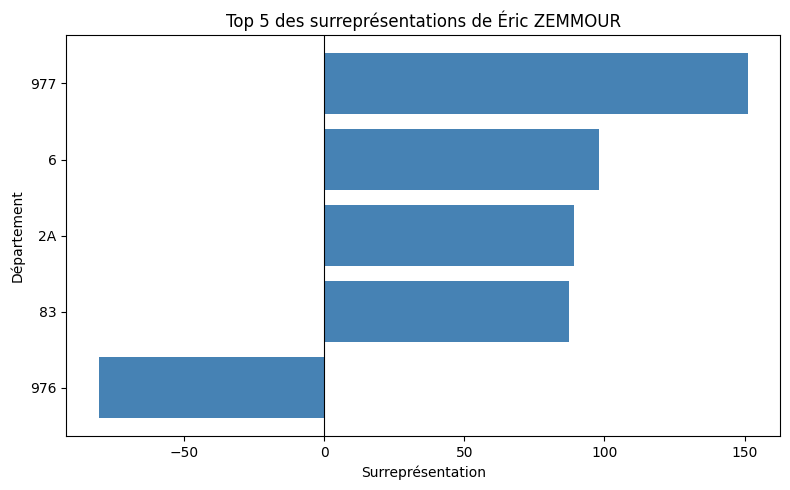

In [10]:
def plot_surrepresentation(candidat, score_departements, n=5):
    """
    Affiche un graphique des principales surreprésentations
    (en valeur absolue) par département pour un candidat donné.

    Paramètres:
        candidat (str): Nom exact du candidat
        score_departements (DataFrame): DataFrame avec les colonnes
                                        'candidat', 'code_departement', 'surrepresentation'
        n (int): Nombre de départements à afficher (défaut: 5)
    """
    # Filtrer pour le candidat
    df_candidat = score_departements[score_departements['candidat'] == candidat].copy()

    # Nettoyer les codes département (enlever .0 sans casser 2A, 2B, etc.)
    df_candidat['code_departement'] = df_candidat['code_departement'].apply(
        lambda x: str(int(float(x))) if str(x).replace('.', '').isnumeric() else str(x)
    )

    # Top n par valeur absolue de surreprésentation
    df_top = df_candidat.reindex(
        df_candidat['surrepresentation'].abs().nlargest(n).index
    )

    # Trier pour affichage (plus grand en haut)
    df_top = df_top.sort_values('surrepresentation')

    # Tracé
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.barh(
        df_top['code_departement'],
        df_top['surrepresentation'],
        color='steelblue'
    )

    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Surreprésentation')
    ax.set_ylabel('Département')
    ax.set_title(f'Top {n} des surreprésentations de {candidat}')

    plt.tight_layout()
    plt.show()

plot_surrepresentation('Éric ZEMMOUR', score_departements)

## 3. Un peu de cartographie
### Question 8

In [11]:
from cartiflette import carti_download
departement_borders = carti_download(
    values = ["France"],
    crs = 4326,
    borders = "DEPARTEMENT",
    vectorfile_format="geojson",
    simplification=50,
    filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022)

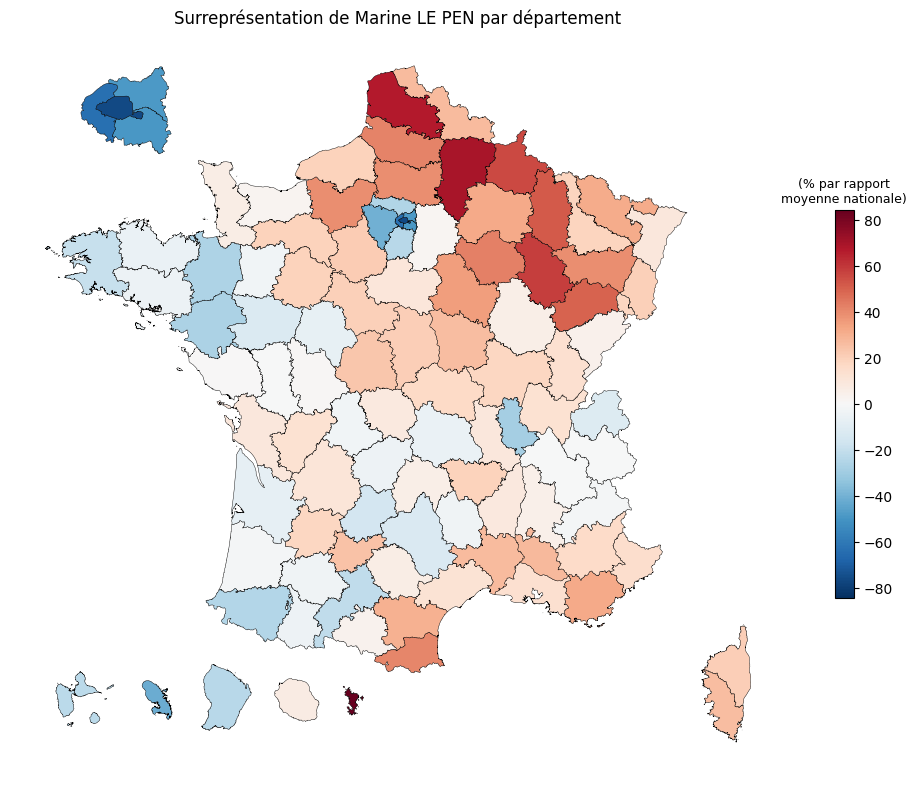

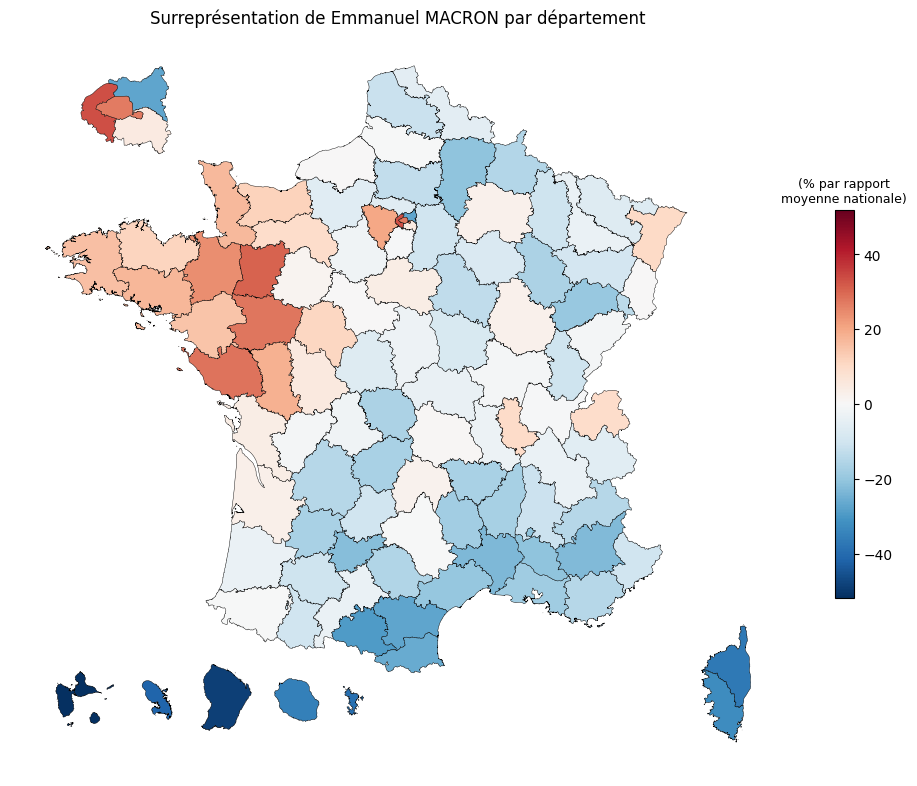

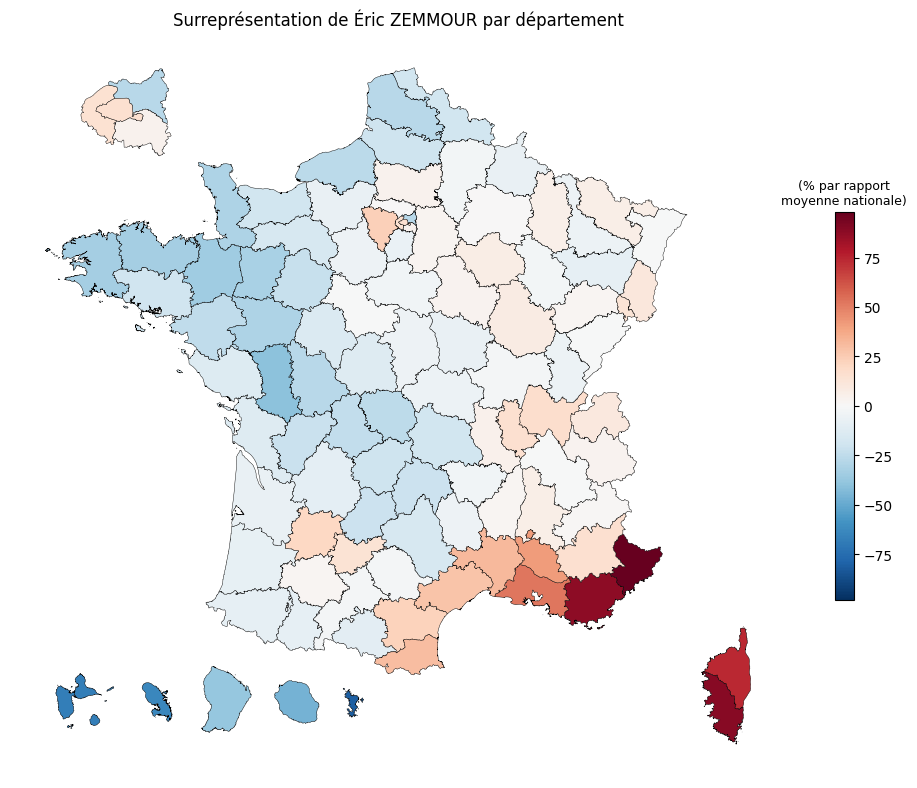

In [12]:
def plot_carte_surrepresentation(candidat, score_departements, departement_borders):
    """
    Affiche une carte choroplèthe de la surreprésentation par département
    pour un candidat donné.

    Paramètres:
        candidat (str): Nom exact du candidat
        score_departements (DataFrame): DataFrame avec les colonnes
                                        'candidat', 'code_departement', 'surrepresentation'
        departement_borders (GeoDataFrame): Fond de carte des départements
    """
    # Filtrer pour le candidat (sans écraser score_departements)
    df_candidat = score_departements[score_departements['candidat'] == candidat].copy()

    # Nettoyer les codes département
    df_candidat = df_candidat[~df_candidat['code_departement'].isin(['fr_etranger'])]
    df_candidat['code_departement'] = df_candidat['code_departement'].apply(
        lambda x: str(int(float(x))).zfill(2) if str(x).replace('.', '').isnumeric() else str(x)
    )

    # Jointure avec le fond de carte
    carte = departement_borders.merge(
        df_candidat[['code_departement', 'surrepresentation']],
        left_on='INSEE_DEP',
        right_on='code_departement',
        how='left'
    )

    # Tracé
    fig, ax = plt.subplots(figsize=(10, 10))

    carte.plot(
        column='surrepresentation',
        cmap='RdBu_r',
        legend=True,
        legend_kwds={'shrink': 0.4},
        vmin=-carte['surrepresentation'].abs().max(),
        vmax=carte['surrepresentation'].abs().max(),
        edgecolor='black',
        linewidth=0.3,
        ax=ax,
        missing_kwds={'color': 'lightgrey'}
    )

    cbar = ax.get_figure().axes[-1]
    cbar.set_title('(% par rapport\nmoyenne nationale)', fontsize=9)

    ax.set_title(f'Surreprésentation de {candidat} par département')
    ax.axis('off')

    plt.tight_layout()
    plt.show()

plot_carte_surrepresentation('Marine LE PEN', score_departements, departement_borders)
plot_carte_surrepresentation('Emmanuel MACRON', score_departements, departement_borders)
plot_carte_surrepresentation('Éric ZEMMOUR', score_departements, departement_borders)